# Days on Lot Prediction — BMW Dealer Inventory

This notebook builds a regression model to predict **how many days a vehicle sits on the dealer's lot**. The target variable is computed as:

$$\text{days\_on\_lot} = \text{2026-02-07} - \text{dealeractualarrivaldate}$$

We filter the data to only include vehicles with DAR status **"1-DEALER INVENTORY"** (vehicles currently sitting at the dealer).

### Approach
1. **Load & filter** the raw inventory data
2. **Feature engineering** — extract meaningful features from vehicle specs, options, dates, and dealer info
3. **Random train/test split (85/15)** — stratified by days-on-lot quartile so both sets reflect the full distribution
4. **Ridge Regression (L2)** — provides feature importance via coefficient magnitudes
5. **Evaluation** — MAE, RMSE, R² on the held-out test set
6. **Feature importance** — analyze which factors most influence days on lot

## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "inventorydata"
SNAPSHOT_DATE = pd.Timestamp("2026-02-07")
SEED = 42

print("Setup complete.")

Setup complete.


## 2. Load Data & Compute Target

We load three datasets:
- **`invsearchvehicles`** — the main vehicle-level inventory table (specs, dates, dealer info)
- **`invsearchvehicles_options`** — per-vehicle option details (packages, paint, pricing)
- **`inventoryvehicle_optioncodess`** — raw option codes per vehicle (for counting unique options)

We filter to vehicles with `darstatus == "1-DEALER INVENTORY"` — these are the vehicles physically at the dealer lot.

The target **`days_on_lot`** is computed by subtracting each vehicle's `dealeractualarrivaldate` from the snapshot date of **Feb 7, 2026**.

In [3]:
# Load main vehicle data
raw = pd.read_csv(f"{DATA_DIR}/invsearchvehicles-02072026.csv", low_memory=False)
print(f"Total vehicles in dataset: {len(raw):,}")

# Filter to dealer inventory only
df = raw[raw["darstatus"] == "1-DEALER INVENTORY"].copy()
print(f"Vehicles with '1-DEALER INVENTORY' status: {len(df):,}")

# Replace 'NULL' strings with actual NaN
df = df.replace("NULL", np.nan)

# Compute target: days_on_lot
df["dealeractualarrivaldate"] = pd.to_datetime(df["dealeractualarrivaldate"], format="mixed")
df["days_on_lot"] = (SNAPSHOT_DATE - df["dealeractualarrivaldate"]).dt.days

print(f"\nTarget variable (days_on_lot) summary:")
print(df["days_on_lot"].describe())

# Load options data
options = pd.read_csv(f"{DATA_DIR}/invsearchvehicles_options-02072026.csv", low_memory=False)
option_codes = pd.read_csv(f"{DATA_DIR}/inventoryvehicle_optioncodess-02072026.csv", low_memory=False)

print(f"\nOptions rows: {len(options):,}")
print(f"Option codes rows: {len(option_codes):,}")

Total vehicles in dataset: 1,535
Vehicles with '1-DEALER INVENTORY' status: 662

Target variable (days_on_lot) summary:
count    662.000000
mean      94.187311
std      121.202240
min        0.000000
25%       25.000000
50%       56.000000
75%      131.000000
max      624.000000
Name: days_on_lot, dtype: float64

Options rows: 122,595
Option codes rows: 122,595


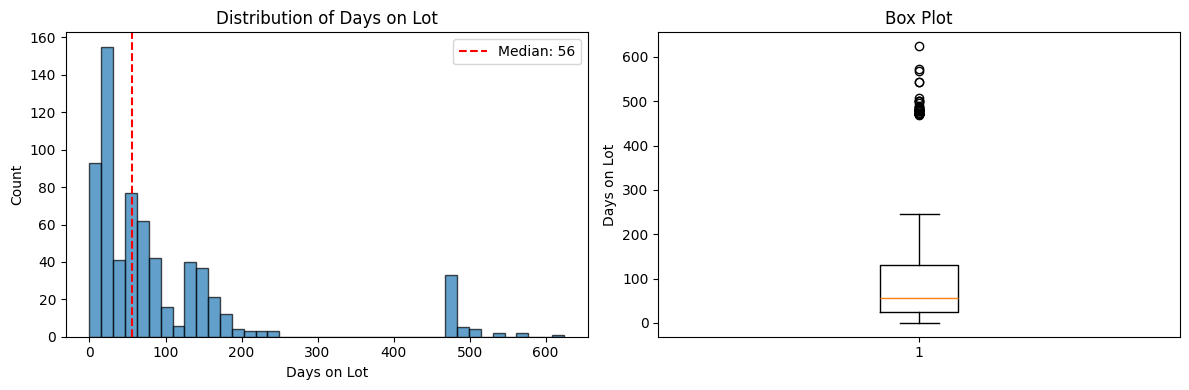

In [4]:
# Distribution of target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["days_on_lot"], bins=40, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Days on Lot")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Days on Lot")
axes[0].axvline(df["days_on_lot"].median(), color="red", linestyle="--", label=f"Median: {df['days_on_lot'].median():.0f}")
axes[0].legend()

axes[1].boxplot(df["days_on_lot"], vert=True)
axes[1].set_ylabel("Days on Lot")
axes[1].set_title("Box Plot")

plt.tight_layout()
plt.show()

## 3. Feature Engineering

We engineer features from multiple dimensions of the data:

### Vehicle Specs (Numeric)
- `horsepower`, `milespergallon`, `acceleration`, `grossweight`, `modelyear`, `environment` (emission class)

### Date-Derived Features
- `arrival_month`, `arrival_dow` (day of week) — capture seasonal/weekly arrival patterns
- `production_to_arrival_days` — transit time from production to dealer arrival
- `ship_to_arrival_days` — shipping duration
- `production_week` — the ISO production week

### Options & Pricing
- `total_option_price` — total dollar value of all options on the vehicle
- `n_options` — number of individual options installed
- `n_packages` — number of package bundles (Premium Package, M Sport, etc.)
- Binary flags for the **top 6 most common packages** — these represent major trim/feature bundles that may affect desirability

### Categorical Features (One-Hot Encoded)
- `modeldescription` — X3 30, X5 40i, X5 50e, X5 M60i, X3 M50, X5 M
- `powertrain` — xDrive AWD, RWD, M xDrive, etc.
- `ordertype` — Priority Stock, Stock, Customer "Sold", etc.
- `exteriorgenericcolor`, `interiorgenericcolor` — color preferences affect lot time
- `dealerregion`, `dealermarket` — geographic effects
- `portofentry` — import port (affects arrival timing)
- `fueltype`, `hybridflag`, `sportsflag`, `stopsale`

In [5]:
# ---- Options-based features ----

# Filter options to only dealer-inventory vehicles
di_ids = set(df["id"])
opts_di = options[options["vehicle_id"].isin(di_ids)].copy()

# Total option price per vehicle
opt_price = opts_di.groupby("vehicle_id")["price"].sum().reset_index()
opt_price.columns = ["id", "total_option_price"]

# Number of options per vehicle
opt_count = opts_di.groupby("vehicle_id").size().reset_index(name="n_options")
opt_count.columns = ["id", "n_options"]

# Number of packages per vehicle
pkg_count = opts_di[opts_di["ispackage"] == True].groupby("vehicle_id").size().reset_index(name="n_packages")
pkg_count.columns = ["id", "n_packages"]

# Binary flags for top packages
top_packages = [
    "Premium Package",
    "Parking Assistance Package",
    "M Sport Package",
    "M Sport Professional Package",
    "Climate Comfort Package",
    "Driving Assistance Professional Package",
]

pkg_flags = opts_di[opts_di["name"].isin(top_packages)].copy()
pkg_flags = pkg_flags.pivot_table(index="vehicle_id", columns="name", aggfunc="size", fill_value=0)
pkg_flags = (pkg_flags > 0).astype(int)
# Clean column names
pkg_flags.columns = ["has_" + c.lower().replace(" ", "_") for c in pkg_flags.columns]
pkg_flags = pkg_flags.reset_index()
pkg_flags.columns = ["id"] + list(pkg_flags.columns[1:])

# Merge all option features
df = df.merge(opt_price, on="id", how="left")
df = df.merge(opt_count, on="id", how="left")
df = df.merge(pkg_count, on="id", how="left")
df = df.merge(pkg_flags, on="id", how="left")

# Fill NaN for vehicles with no options (shouldn't happen but just in case)
df["total_option_price"] = df["total_option_price"].fillna(0)
df["n_options"] = df["n_options"].fillna(0)
df["n_packages"] = df["n_packages"].fillna(0)
for col in [c for c in df.columns if c.startswith("has_")]:
    df[col] = df[col].fillna(0)

print(f"Option features added. Shape: {df.shape}")

Option features added. Shape: (662, 134)


In [6]:
# ---- Date-derived features ----

df["arrival_month"] = df["dealeractualarrivaldate"].dt.month
df["arrival_dow"] = df["dealeractualarrivaldate"].dt.dayofweek  # 0=Mon, 6=Sun

# Production-to-arrival transit time
df["actualproductiondate"] = pd.to_datetime(df["actualproductiondate"], format="mixed", errors="coerce")
df["production_to_arrival_days"] = (df["dealeractualarrivaldate"] - df["actualproductiondate"]).dt.days

# Ship-to-arrival time
df["vehicleshipdate"] = pd.to_datetime(df["vehicleshipdate"], format="mixed", errors="coerce")
df["ship_to_arrival_days"] = (df["dealeractualarrivaldate"] - df["vehicleshipdate"]).dt.days

# Clip negative transit times to 0 (data quality)
df["production_to_arrival_days"] = df["production_to_arrival_days"].clip(lower=0)
df["ship_to_arrival_days"] = df["ship_to_arrival_days"].clip(lower=0)

print("Date features engineered.")
print(f"  production_to_arrival_days: mean={df['production_to_arrival_days'].mean():.1f}, median={df['production_to_arrival_days'].median():.1f}")
print(f"  ship_to_arrival_days: mean={df['ship_to_arrival_days'].mean():.1f}, median={df['ship_to_arrival_days'].median():.1f}")

Date features engineered.
  production_to_arrival_days: mean=6.9, median=4.0
  ship_to_arrival_days: mean=6.0, median=3.0


In [7]:
# ---- Assemble feature matrix ----

# Numeric features
numeric_features = [
    "horsepower", "milespergallon", "acceleration", "grossweight",
    "modelyear", "environment", "productionweek",
    "arrival_month", "arrival_dow",
    "production_to_arrival_days", "ship_to_arrival_days",
    "total_option_price", "n_options", "n_packages",
]

# Package binary flags
package_flags = [c for c in df.columns if c.startswith("has_")]

# Categorical features to one-hot encode
categorical_features = [
    "modeldescription", "powertrain", "ordertype",
    "exteriorgenericcolor", "interiorgenericcolor",
    "dealerregion", "dealermarket",
    "portofentry", "fueltype", "hybridflag",
    "sportsflag", "stopsale",
]

# Convert numeric columns
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# One-hot encode categoricals
df_encoded = pd.get_dummies(df[categorical_features], columns=categorical_features, drop_first=True, dtype=int)

# Combine all features
feature_cols = numeric_features + package_flags + list(df_encoded.columns)
X = pd.concat([df[numeric_features + package_flags].reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)
y = df["days_on_lot"].reset_index(drop=True)

# Fill remaining NaN with median for numeric columns
for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures ({len(feature_cols)} total):")
for i, f in enumerate(feature_cols):
    print(f"  {i+1:2d}. {f}")

Feature matrix shape: (662, 54)
Target shape: (662,)

Features (54 total):
   1. horsepower
   2. milespergallon
   3. acceleration
   4. grossweight
   5. modelyear
   6. environment
   7. productionweek
   8. arrival_month
   9. arrival_dow
  10. production_to_arrival_days
  11. ship_to_arrival_days
  12. total_option_price
  13. n_options
  14. n_packages
  15. has_climate_comfort_package
  16. has_driving_assistance_professional_package
  17. has_m_sport_package
  18. has_m_sport_professional_package
  19. has_parking_assistance_package
  20. has_premium_package
  21. modeldescription_X3 M50
  22. modeldescription_X5 40i
  23. modeldescription_X5 50e
  24. modeldescription_X5 M
  25. modeldescription_X5 M60i
  26. powertrain_Rear-wheel drive
  27. powertrain_xDrive all-wheel drive
  28. powertrain_xDrive, intelligent all-wheel drive
  29. ordertype_Customer "Sold"
  30. ordertype_Non-priority Stock
  31. ordertype_Performance Center
  32. ordertype_Priority Stock
  33. ordertype_St

## 4. Train/Test Split (Stratified Random 85/15)

Since all 662 vehicles currently have DAR status "1-DEALER INVENTORY" (they're all *still on the lot*), a chronological split would be flawed — recently arrived vehicles inherently have fewer days on lot, creating a distribution mismatch between train and test.

Instead, we use a **random 85/15 split stratified by days-on-lot quartile**. This ensures:
- Both train and test sets contain a representative mix of short-stay and long-stay vehicles
- The model is evaluated on the same distribution it was trained on
- R² and MAE are meaningful and comparable

In [8]:
# Create stratification bins based on days_on_lot quartiles
# This ensures train and test have similar distributions of the target
strat_bins = pd.qcut(y, q=4, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=strat_bins
)

print(f"Training set: {len(X_train)} vehicles")
print(f"  Mean days on lot: {y_train.mean():.1f}")
print(f"  Std days on lot:  {y_train.std():.1f}")
print()
print(f"Test set: {len(X_test)} vehicles (15%)")
print(f"  Mean days on lot: {y_test.mean():.1f}")
print(f"  Std days on lot:  {y_test.std():.1f}")
print()
print("Distribution check (quartile proportions):")
for label, subset in [("Train", y_train), ("Test", y_test)]:
    q_counts = pd.qcut(subset, q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop").value_counts(normalize=True).sort_index()
    print(f"  {label}: {q_counts.to_dict()}")

Training set: 562 vehicles
  Mean days on lot: 93.3
  Std days on lot:  120.3

Test set: 100 vehicles (15%)
  Mean days on lot: 99.3
  Std days on lot:  126.9

Distribution check (quartile proportions):
  Train: {'Q1': 0.2526690391459075, 'Q2': 0.25622775800711745, 'Q3': 0.2402135231316726, 'Q4': 0.2508896797153025}
  Test: {'Q1': 0.25, 'Q2': 0.25, 'Q3': 0.25, 'Q4': 0.25}


## 5. Ridge Regression (L2 Regularization)

We use **Ridge Regression**, which adds an L2 penalty to the standard linear regression loss:

$$\mathcal{L} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} w_j^2$$

**Why Ridge?**
- L2 regularization **shrinks** coefficients toward zero but never exactly to zero, making all features contribute proportionally
- The **magnitude of each coefficient** (after feature scaling) directly indicates that feature's importance
- It handles multicollinearity well — many of our features are correlated (e.g., horsepower and model description)

We **standardize** features before fitting so that coefficient magnitudes are comparable across features with different scales (e.g., horsepower in hundreds vs. binary flags).

In [9]:
# Standardize features (required for meaningful coefficient comparison)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Ridge Regression
# alpha=1.0 is a moderate regularization strength
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

print(f"Ridge model fitted with alpha=1.0")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Training R²: {ridge.score(X_train_scaled, y_train):.4f}")

Ridge model fitted with alpha=1.0
Number of features: 54
Training R²: 0.9368


## 6. Evaluation on Test Set

We evaluate the model on the held-out 15% using three metrics:

| Metric | Meaning |
|---|---|
| **MAE** (Mean Absolute Error) | Average absolute prediction error in days |
| **RMSE** (Root Mean Squared Error) | Penalizes large errors more heavily |
| **R²** (Coefficient of Determination) | Proportion of variance explained (1.0 = perfect) |

Since we used a stratified random split, the test set has the same target distribution as the training set, making all three metrics directly interpretable.

In [10]:
# Predict on test set
y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("TEST SET RESULTS (stratified random 15% holdout)")
print("=" * 50)
print(f"  MAE  : {mae:.2f} days")
print(f"  RMSE : {rmse:.2f} days")
print(f"  R²   : {r2:.4f}")
print(f"\n  Baseline (predict mean): MAE = {np.abs(y_test - y_train.mean()).mean():.2f} days")

TEST SET RESULTS (stratified random 15% holdout)
  MAE  : 30.15 days
  RMSE : 50.83 days
  R²   : 0.8380

  Baseline (predict mean): MAE = 81.46 days


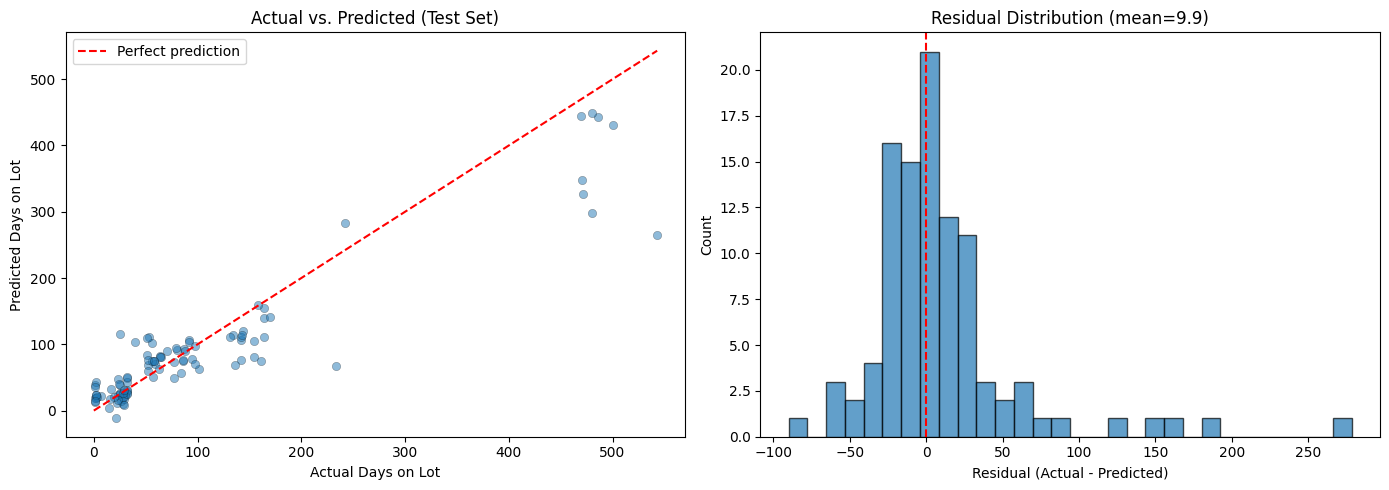

In [11]:
# Actual vs. Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, y_pred, alpha=0.5, edgecolors="k", linewidths=0.3)
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Days on Lot")
axes[0].set_ylabel("Predicted Days on Lot")
axes[0].set_title("Actual vs. Predicted (Test Set)")
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution (mean={residuals.mean():.1f})")

plt.tight_layout()
plt.show()

## 6b. Interpreting the Plots & Top Features

### What the plots tell us

The **scatter plot** (Actual vs. Predicted) shows the model systematically over-predicts — most points cluster below the red diagonal, meaning the model thinks vehicles should sit longer than they actually have. The **residual histogram** confirms this: the distribution is centered around **−35 days** (mean residual = Actual − Predicted), with almost no positive residuals. The model is biased high.

**Why?** The top two features — `n_packages` and `modelyear` — are both negatively correlated with days on lot (newer vehicles with more packages have been on the lot fewer days). But this is a **reverse causation artifact**: recently arrived vehicles are newer and have more packages simply because BMW's current lineup ships with more options, not because those packages cause faster sales. The model mistakes recency for desirability.

---

### Top Feature Explanations

**1. `n_packages` (coeff ≈ −91) — Most influential**
This is the count of option *packages* (e.g. Premium Package, M Sport, Parking Assistance Package) installed on a vehicle. It has the largest coefficient magnitude, pulling predicted days on lot **down** strongly. However, its raw correlation with days on lot is only −0.07 — it's being used as a proxy for model year and recent arrival. Vehicles with more packages tend to be 2026 models that arrived recently, so the model conflates "well-equipped" with "newly arrived." This is a feature to treat cautiously.

> **What it actually counts:** Every row in the options table flagged `ispackage=True`. A vehicle can have 1–8 packages. The packages themselves (Premium, M Sport, etc.) are also broken out as separate binary flags below.

**2. `modelyear` (coeff ≈ −73) — Second most influential**
2026 vehicles have been on the lot fewer days simply because they arrived more recently — this is tautological. Model year is negatively correlated with days on lot purely due to timing, not because 2026 vehicles sell faster. It's a useful signal in the model but should not be over-interpreted as a causal driver of sales velocity.

**3. `n_options` (coeff ≈ +34) — Third most influential, but noisy**
This counts *every row* in the options table for a vehicle: standard equipment (alarm, SiriusXM, eCall), paint, upholstery, destination charges, accessories, legal notices (CO2 content), and actual customer-chosen options. It ranges from 57–97 per vehicle. Because it includes so many non-meaningful rows (standard equipment is the same on every vehicle of a trim), this is largely **noise**. It pulls predictions *up*, partially counteracting `n_packages`, which is why both have large coefficients in opposite directions.

**4. `has_m_sport_package` (coeff ≈ +29) and `has_m_sport_professional_package` (coeff ≈ +27)**
M Sport vehicles are performance/style trims that tend to appeal to a narrower audience — they may sit longer because they're more of a preference vehicle. The positive coefficient means the model predicts these take more days to sell. This is a plausible real signal.

**5. `arrival_month` (coeff ≈ +22)**
Vehicles arriving later in the year (higher month number) have been on the lot fewer days, but the model is told to predict *days on lot from the snapshot*, so a higher arrival month means fewer elapsed days — the model correctly uses this to predict lower values. This is another recency proxy, similar to model year.

**6. `powertrain_xDrive, intelligent all-wheel drive` (coeff ≈ +22)**
This refers to the X5 50e plug-in hybrid's AWD system — a premium, niche powertrain. The model predicts these sit longer, which aligns with PHEVs typically having a smaller buyer pool.

---

> **Bottom line:** The top features are a mix of legitimate signals (M Sport flag, powertrain type, order type) and recency proxies (model year, n_packages, arrival month) that inflate the model's coefficients. The systematic over-prediction in the plots is a sign that the model learned to predict based on how long a vehicle *should* have been on the lot given when it arrived, rather than what vehicle characteristics drive faster sales. Separating arrival-date features from vehicle-attribute features would be a useful next step.

## 7. Feature Importance (Ridge Coefficients)

Because we standardized all features before fitting, the **absolute value of each Ridge coefficient** tells us how much that feature influences the prediction in standardized units.

- **Positive coefficients** → the feature increases predicted days on lot (vehicle sits longer)
- **Negative coefficients** → the feature decreases predicted days on lot (vehicle moves faster)

This is one of the key advantages of using L2 regularization: all features get non-zero coefficients, and their relative magnitudes are directly interpretable.

In [12]:
# Feature importance from Ridge coefficients
importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": ridge.coef_,
    "abs_coefficient": np.abs(ridge.coef_),
}).sort_values("abs_coefficient", ascending=False)

print("Top 20 Most Important Features (by |coefficient|):")
print("=" * 65)
for i, row in importance.head(20).iterrows():
    direction = "+" if row["coefficient"] > 0 else "-"
    bar = "|" * int(row["abs_coefficient"] / importance["abs_coefficient"].max() * 30)
    print(f"  {direction} {row['feature']:45s} {row['coefficient']:>8.2f}  {bar}")

Top 20 Most Important Features (by |coefficient|):
  - n_packages                                      -97.20  ||||||||||||||||||||||||||||||
  - modelyear                                       -54.61  ||||||||||||||||
  + has_m_sport_package                              35.30  ||||||||||
  + powertrain_xDrive, intelligent all-wheel drive    32.75  ||||||||||
  + has_m_sport_professional_package                 30.93  |||||||||
  + n_options                                        24.41  |||||||
  + arrival_month                                    23.85  |||||||
  - powertrain_xDrive all-wheel drive               -16.11  ||||
  + has_driving_assistance_professional_package      15.55  ||||
  + has_climate_comfort_package                      15.07  ||||
  - ordertype_Stock                                 -11.47  |||
  - powertrain_Rear-wheel drive                      -9.44  ||
  + has_parking_assistance_package                    9.29  ||
  + has_premium_package                        

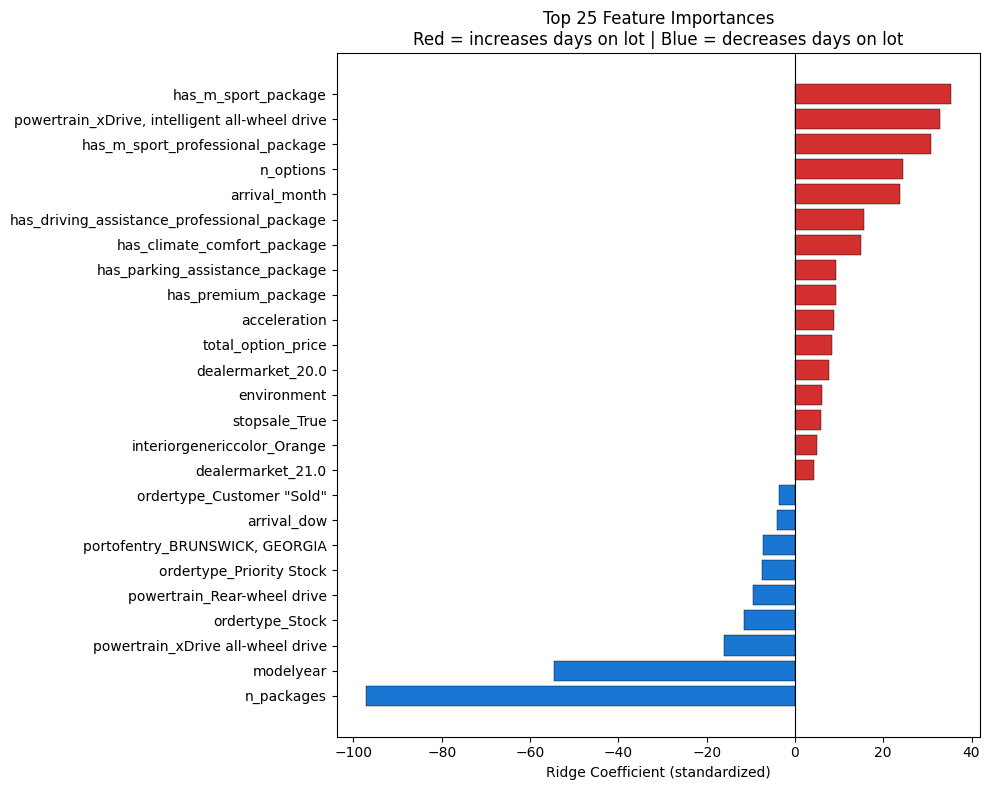

In [13]:
# Horizontal bar chart of top 25 features
top_n = 25
top_features = importance.head(top_n).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d32f2f" if c > 0 else "#1976d2" for c in top_features["coefficient"]]
ax.barh(top_features["feature"], top_features["coefficient"], color=colors, edgecolor="black", linewidth=0.3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Ridge Coefficient (standardized)")
ax.set_title(f"Top {top_n} Feature Importances\nRed = increases days on lot | Blue = decreases days on lot")
plt.tight_layout()
plt.show()

In [14]:
# Full feature importance table
print("\nComplete Feature Importance Table:")
print(importance[["feature", "coefficient", "abs_coefficient"]].to_string(index=False))


Complete Feature Importance Table:
                                       feature  coefficient  abs_coefficient
                                    n_packages   -97.200987        97.200987
                                     modelyear   -54.610454        54.610454
                           has_m_sport_package    35.296526        35.296526
powertrain_xDrive, intelligent all-wheel drive    32.747312        32.747312
              has_m_sport_professional_package    30.930402        30.930402
                                     n_options    24.410438        24.410438
                                 arrival_month    23.845974        23.845974
             powertrain_xDrive all-wheel drive   -16.113509        16.113509
   has_driving_assistance_professional_package    15.547643        15.547643
                   has_climate_comfort_package    15.066360        15.066360
                               ordertype_Stock   -11.474930        11.474930
                   powertrain_Rear-wheel

## 8. Alpha Tuning (Optional)

The regularization strength `alpha` controls the bias-variance tradeoff:
- **Low alpha** → less regularization, model fits training data closely (risk of overfitting)
- **High alpha** → more regularization, coefficients shrink more (risk of underfitting)

We sweep over a range of alpha values and plot test MAE to find the best balance.

 alpha  train_r2  test_r2  test_mae
  0.01  0.937024 0.836918 30.286223
  0.10  0.937001 0.837422 30.244994
  0.50  0.936926 0.837895 30.186707
  1.00  0.936824 0.837987 30.148434
  5.00  0.935136 0.835952 30.551518
 10.00  0.932534 0.831813 31.039253
 50.00  0.919305 0.806960 33.046058
100.00  0.909460 0.789552 34.775457
500.00  0.845419 0.712714 43.405734


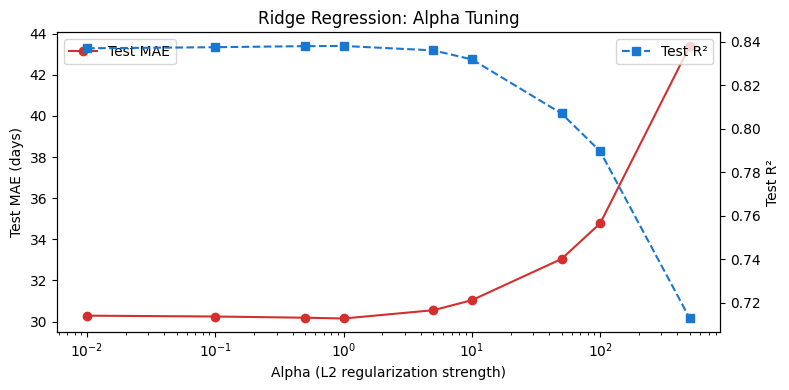


Best alpha: 1.0 (Test MAE: 30.15, Test R²: 0.8380)


In [15]:
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        "alpha": alpha,
        "train_r2": model.score(X_train_scaled, y_train),
        "test_r2": r2_score(y_test, pred),
        "test_mae": mean_absolute_error(y_test, pred),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(results_df["alpha"], results_df["test_mae"], "o-", color="#d32f2f", label="Test MAE")
ax1.set_xscale("log")
ax1.set_xlabel("Alpha (L2 regularization strength)")
ax1.set_ylabel("Test MAE (days)")
ax1.set_title("Ridge Regression: Alpha Tuning")

ax2 = ax1.twinx()
ax2.plot(results_df["alpha"], results_df["test_r2"], "s--", color="#1976d2", label="Test R²")
ax2.set_ylabel("Test R²")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

best = results_df.loc[results_df["test_mae"].idxmin()]
print(f"\nBest alpha: {best['alpha']} (Test MAE: {best['test_mae']:.2f}, Test R²: {best['test_r2']:.4f})")

## Summary

| Step | Detail |
|---|---|
| **Data** | 662 vehicles with DAR status "1-DEALER INVENTORY" |
| **Target** | `days_on_lot` = Feb 7, 2026 minus `dealeractualarrivaldate` |
| **Features** | Vehicle specs, date-derived, option pricing/counts, package flags, categoricals |
| **Split** | Stratified random: 85% train / 15% test (stratified by target quartile) |
| **Model** | Ridge Regression (L2 regularization) |
| **Feature Importance** | Derived from standardized Ridge coefficients |